# 00 — One-time Global-6 hyperparameter optimization

This is the only place where global parameters are selected. The saved model uses sensors 1–6 and subsensor 0; sensor 7 is excluded.

In [1]:
from pathlib import Path
import sys, json, numpy as np, matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd().resolve(),*Path.cwd().resolve().parents) if (p/"Networks"/"TCOCNNv3.py").exists())
sys.path[:0]=[str(ROOT/"Networks"),str(ROOT/"Evaluation Seminar"/"Day_03"),str(ROOT/"Evaluation Seminar"/"Day_04")]
from IPython.display import Image,display
OUTPUT=ROOT/"artifacts"/"seminar_day4_global6_hpo"
RUN_HPO=False
print("Using saved HPO:",OUTPUT)
if not (OUTPUT/"source_global6_hpo"/"weights.pt").exists():
 raise FileNotFoundError("Run 00_Global6_Hyperparameter_Optimization.py once.")

Using saved HPO: \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_global6_hpo


## Saved winner

In [2]:
best=json.loads((OUTPUT/"best_hyperparameters.json").read_text())
meta=json.loads((OUTPUT/"source_global6_hpo"/"metadata.json").read_text())
assert best["test_or_target7_used"] is False
summary={"trial":best["selected_trial"],"best epoch":best["best_epoch"],
 "validation UGM RMSE [ppb]":best["best_validation_UGM_RMSE_ppb"],
 "parameters":meta["parameter_count"],"masters":best["sources"],"excluded":best["excluded_target"]}
try:
 import pandas as pd; display(pd.DataFrame([summary])); display(pd.DataFrame([best["params"]]).T)
except ImportError: print(summary,best["params"])

{'trial': 21, 'best epoch': 86, 'validation UGM RMSE [ppb]': 26.292286880580235, 'parameters': 144097, 'masters': ['54118801', '54120037', '54120457', '54156953', '84746449', '84748697'], 'excluded': '84749569'} {'n_filter': 16, 'section_depth': 4, 'convs_per_block': 3, 'channel_growth': 8, 'kernel': 15, 'stride': 4, 'num_neurons': 64, 'drop_out': 0.3, 'initial_learning_rate': 0.0001392233227508233, 'batch_size': 64, 'residual': False}


## Search and training visualizations

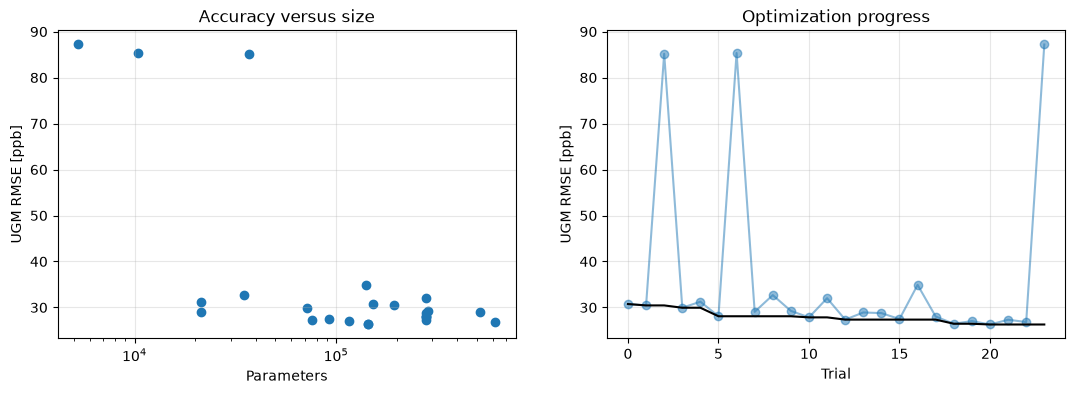

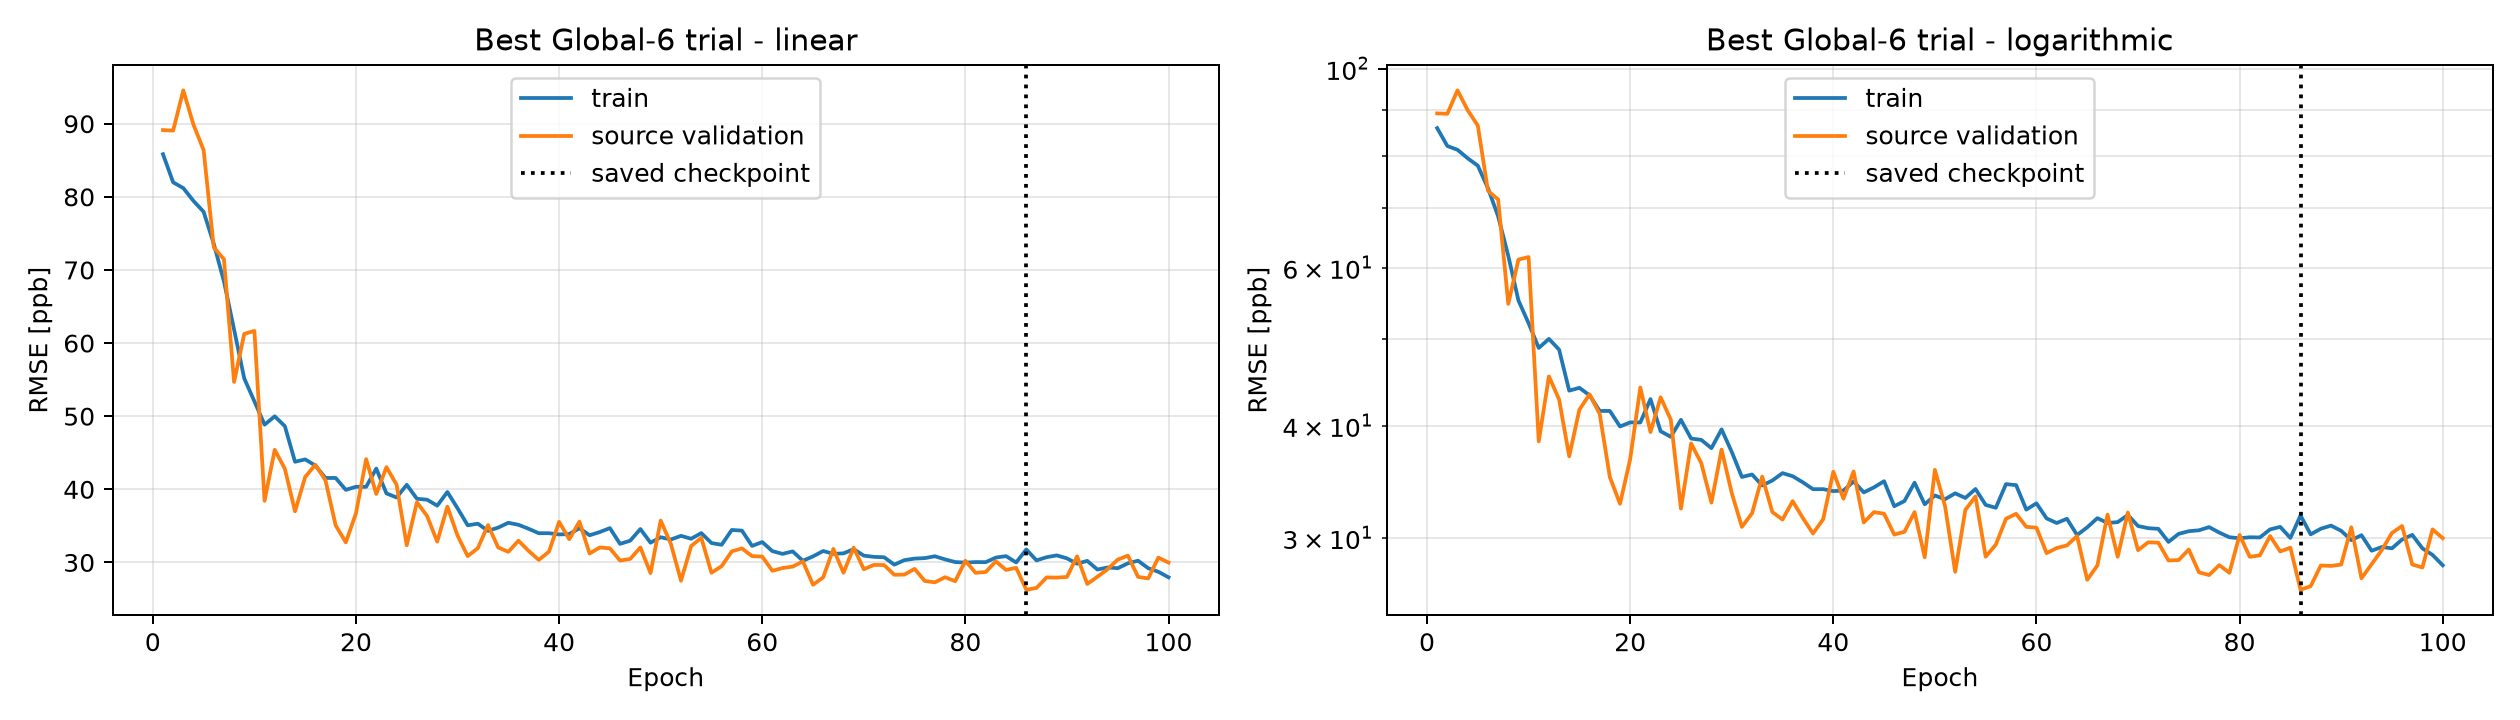

In [3]:
trials=[r for r in json.loads((OUTPUT/"trials.json").read_text()) if r.get("status")=="ok"]
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].scatter([r["parameter_count"] for r in trials],[r["UGM_RMSE_ppb"] for r in trials])
scores=np.asarray([r["UGM_RMSE_ppb"] for r in trials])
axes[1].plot(scores,marker="o",alpha=.5); axes[1].plot(np.minimum.accumulate(scores),color="black")
axes[0].set(xscale="log",title="Accuracy versus size",xlabel="Parameters",ylabel="UGM RMSE [ppb]")
axes[1].set(title="Optimization progress",xlabel="Trial",ylabel="UGM RMSE [ppb]")
for ax in axes: ax.grid(True,alpha=.3)
plt.show(); display(Image(filename=str(OUTPUT/"best_training_curve.png")))

Notebook 01 now loads the saved weights, scaler, and parameters. Global training is not repeated.